# 01 · Crescimento e ticket médio do Pix

**Perguntas de negócio deste notebook**
1. Quanto o Pix cresceu desde o lançamento (nov/2020), em **quantidade** e em **valor**? O crescimento está **desacelerando**?
2. O **ticket médio** (valor médio por Pix) está subindo ou caindo? O que isso diz sobre o uso?

**Dados:** estatísticas nacionais de transações Pix do Banco Central (`data/raw/estatisticas.parquet`), coletadas automaticamente por `src/coleta.py`.

> 💡 **Rodando no Google Colab?** Rode antes, numa célula:
> `!git clone https://github.com/HagataMendes/pix-brasil-analise.git` e depois `%cd pix-brasil-analise/notebooks`

## 1. Preparando o ambiente

Importamos as bibliotecas e o nosso módulo de estilo (`src/estilo.py`), que deixa todos os gráficos do projeto com a mesma identidade visual — cores, fontes e grade.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import estilo
from estilo import br

estilo.aplicar()
pd.set_option("display.float_format", lambda v: br(v, 2))

## 2. Carregando os dados

O arquivo está em **Parquet**, um formato colunar e compactado: 740 mil linhas ocupam ~10 MB, e podemos ler só as colunas que vamos usar (`columns=`), o que deixa tudo mais rápido.

In [2]:
df = pd.read_parquet(RAIZ / "data/raw/estatisticas.parquet", columns=["AnoMes", "VALOR", "QUANTIDADE"])
print(f"{len(df):,} linhas".replace(",", "."))
df.head()

741.383 linhas


,AnoMes,VALOR,QUANTIDADE
0,202011,"58.585,51",123
1,202011,"202.074,31",130
2,202011,"2.888.502,20",966
3,202011,"8.032,96",29
4,202011,"40,00",3


Cada linha **não é uma transação**: é um *grupo* de transações com as mesmas características (quem pagou, quem recebeu, região, idade…) num mês, com o **valor total** e a **quantidade** daquele grupo. Por isso, para ter o total do mês, **somamos** todas as linhas de cada `AnoMes`.

## 3. Montando a série mensal

Três passos:
1. `groupby("AnoMes").sum()` → soma valor e quantidade por mês;
2. convertemos `202608` em data de verdade (`2026-08-01`), o que faz os gráficos entenderem o tempo;
3. criamos o **ticket médio** = valor ÷ quantidade.

In [3]:
mensal = df.groupby("AnoMes")[["VALOR", "QUANTIDADE"]].sum()
mensal.index = pd.to_datetime(mensal.index.astype(str), format="%Y%m")
mensal.index.name = "mes"
mensal["ticket_medio"] = mensal["VALOR"] / mensal["QUANTIDADE"]

# unidades mais legíveis para os gráficos
mensal["qtd_bilhoes"] = mensal["QUANTIDADE"] / 1e9
mensal["valor_trilhoes"] = mensal["VALOR"] / 1e12

ultimo = mensal.index.max()
print("Período:", mensal.index.min().strftime("%m/%Y"), "a", ultimo.strftime("%m/%Y"), f"({len(mensal)} meses)")
mensal.tail()

Período: 11/2020 a 08/2026 (70 meses)


,VALOR,QUANTIDADE,ticket_medio,qtd_bilhoes,valor_trilhoes
mes,,,,,
2026-04-01,"2.896.675.312.318,11",6680896774,"433,58","6,68","2,90"
2026-05-01,"2.957.488.405.988,77",7121879045,"415,27","7,12","2,96"
2026-06-01,"3.044.127.221.869,05",6982273524,"435,98","6,98","3,04"
2026-07-01,"3.223.292.570.448,90",7238374542,"445,31","7,24","3,22"
2026-08-01,"3.174.483.088.769,54",7366981446,"430,91","7,37","3,17"


> ⚠️ **Checagem de qualidade:** a base de municípios já traz setembro/2026, mas o mês ainda não terminou — usar um mês incompleto faria parecer uma queda que não existe. Aqui usamos a base nacional, que vai até **agosto/2026**, o último mês fechado.

## 4. Pergunta 1 — Quanto o Pix cresceu?

Mostramos **quantidade** e **valor** em dois gráficos lado a lado, cada um com o seu eixo. (Evitamos o gráfico de "dois eixos Y" no mesmo quadro: ele engana, porque a escala de um pode fazer a outra linha parecer maior ou menor do que é.)

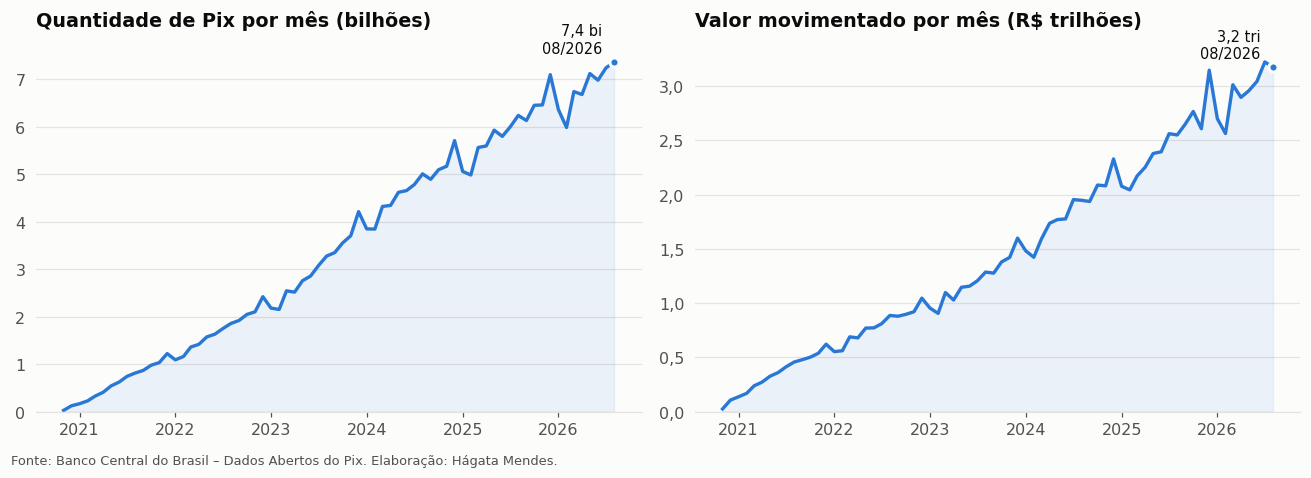

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col, titulo, suf, casas in [
    (ax1, "qtd_bilhoes", "Quantidade de Pix por mês (bilhões)", " bi", 1),
    (ax2, "valor_trilhoes", "Valor movimentado por mês (R$ trilhões)", " tri", 1),
]:
    ax.plot(mensal.index, mensal[col], color=estilo.AZUL)
    ax.fill_between(mensal.index, mensal[col], color=estilo.AZUL, alpha=0.08)
    v = mensal[col].iloc[-1]
    ax.scatter([ultimo], [v], s=36, color=estilo.AZUL, zorder=3, edgecolor=estilo.FUNDO, linewidth=2)
    ax.annotate(f"{br(v, casas)}{suf}\n{ultimo:%m/%Y}", (ultimo, v), xytext=(-8, 6),
                textcoords="offset points", ha="right", color=estilo.TEXTO, fontsize=9.5)
    ax.set_title(titulo)
    ax.set_ylim(0)
    estilo.eixo_br(ax, 0 if col == "qtd_bilhoes" else 1)

estilo.fonte(fig)
plt.tight_layout()
plt.show()

Crescimento enorme — mas "crescimento enorme" não responde se está **desacelerando**. Para isso, precisamos de uma taxa de crescimento.

### Comparando o que é comparável

2026 ainda não acabou (temos até agosto). Comparar o **ano todo** de 2025 com **8 meses** de 2026 seria injusto. A solução clássica é o **acumulado no ano (YTD, *year-to-date*)**: somamos **janeiro a agosto** de cada ano e comparamos com janeiro–agosto do ano anterior. Assim toda comparação tem o mesmo número de meses.

In [5]:
mes_corte = ultimo.month  # 8 = agosto
ytd = mensal[mensal.index.month <= mes_corte]
ytd = ytd.groupby(ytd.index.year)[["QUANTIDADE", "VALOR"]].sum()
ytd = ytd.loc[2021:]  # 2020 só tem nov e dez: fica de fora

cresc = (ytd.pct_change() * 100).dropna().rename(columns={"QUANTIDADE": "cresc_qtd_%", "VALOR": "cresc_valor_%"})
cresc

,cresc_qtd_%,cresc_valor_%
mes,,
2022,"206,48","140,76"
2023,"80,29","53,37"
2024,"65,80","55,74"
2025,"27,47","34,72"
2026,"20,61","27,86"


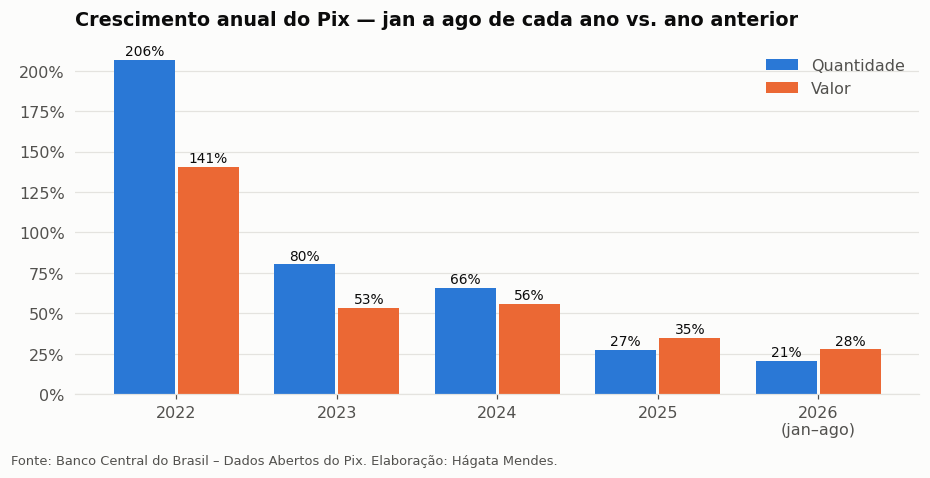

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
anos = cresc.index.astype(str)
x = range(len(anos))
larg = 0.38
b1 = ax.bar([i - larg / 2 - 0.01 for i in x], cresc["cresc_qtd_%"], larg, color=estilo.AZUL, label="Quantidade")
b2 = ax.bar([i + larg / 2 + 0.01 for i in x], cresc["cresc_valor_%"], larg, color=estilo.LARANJA, label="Valor")
for barras in (b1, b2):
    for b in barras:
        ax.annotate(f"{br(b.get_height(), 0)}%", (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, color=estilo.TEXTO)
ax.set_xticks(list(x), [f"{a}\n(jan–{estilo.mes_abrev(ultimo)})" if a == anos[-1] else a for a in anos])
ax.set_title(f"Crescimento anual do Pix — jan a {estilo.mes_abrev(ultimo)} de cada ano vs. ano anterior")
estilo.eixo_br(ax, 0, "%")
ax.legend(loc="upper right")
estilo.fonte(fig)
plt.tight_layout()
plt.show()

**Leitura do gráfico**
- O crescimento **está desacelerando**, e isso é esperado: é muito mais fácil dobrar de tamanho quando se é pequeno. A quantidade saiu de **+206%** em 2022 para **+21%** em 2026.
- Mesmo assim, crescer cerca de 20% ao ano sobre uma base de **71,3 bilhões de transações** (total de 2025) é muito. É um produto **maduro, mas ainda em expansão**.
- 📅 **Sazonalidade:** repare nos picos de **dezembro** (13º salário e compras de fim de ano) e na queda de cerca de **10% em janeiro**, logo depois das festas, que se repete todo ano.
- 👀 **Detalhe importante:** desde 2025 o **valor cresce mais rápido que a quantidade** (em 2026: valor +28% contra quantidade +21%). Se o dinheiro cresce mais que o número de Pix, o valor médio de cada Pix está **subindo**. É a pergunta 2.

## 5. Pergunta 2 — O ticket médio

**Ticket médio = valor total ÷ quantidade de transações.** Ele responde "quanto vale um Pix típico". Se cai, o Pix está sendo usado para compras menores do dia a dia (padaria, transporte); se sobe, entram pagamentos maiores (contas, fornecedores, salários).

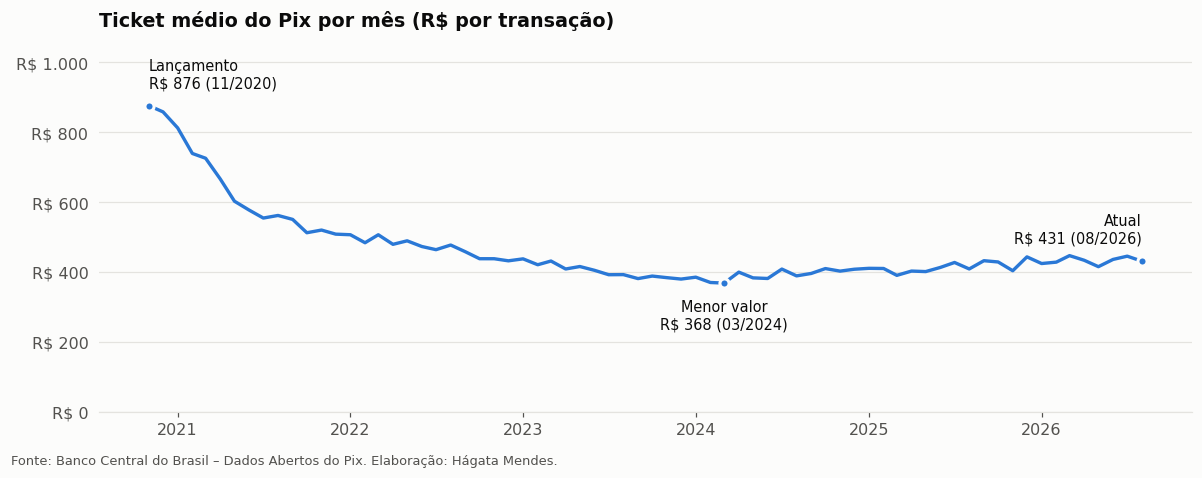

In [7]:
t = mensal["ticket_medio"]
pontos = {"Lançamento": t.index[0], "Menor valor": t.idxmin(), "Atual": t.index[-1]}

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(t.index, t, color=estilo.AZUL)
for rotulo, data in pontos.items():
    v = t[data]
    ax.scatter([data], [v], s=36, color=estilo.AZUL, zorder=3, edgecolor=estilo.FUNDO, linewidth=2)
    ax.annotate(f"{rotulo}\nR$ {br(v, 0)} ({data:%m/%Y})", (data, v), xytext=(0, 12 if rotulo != "Menor valor" else -30),
                textcoords="offset points", ha="left" if rotulo == "Lançamento" else ("right" if rotulo == "Atual" else "center"),
                fontsize=9.5, color=estilo.TEXTO)
ax.set_title("Ticket médio do Pix por mês (R$ por transação)")
ax.set_ylim(0, t.max() * 1.2)
estilo.eixo_br(ax, 0, prefixo="R$ ")
estilo.fonte(fig)
plt.tight_layout()
plt.show()

**Leitura do gráfico: a curva tem duas fases**
1. **Queda (2020–2024):** o ticket caiu de **R$ 876** no lançamento para **R$ 368** em 03/2024. No começo, o Pix era usado para transferências maiores (quem já fazia TED passou a usar Pix). Conforme a população adotou, ele entrou nos **pagamentos pequenos do dia a dia**, e a média despencou.
2. **Retomada (2024 em diante):** o ticket voltou a subir e chegou a **R$ 431** em 08/2026 (**+17%** desde o mínimo). É uma **hipótese** a testar: empresas passando a usar Pix para pagamentos maiores (fornecedores, salários, contas), no lugar de TED e boleto.

> ⚠️ **Cuidado analítico:** os valores são **nominais**, sem correção pela inflação. Parte dessa alta é só a inflação do período. Corrigir pelo IPCA seria uma boa melhoria para uma próxima versão.

## 6. Conclusões

| | Resultado |
|---|---|
| **Tamanho** | Em 2025 foram **71,3 bilhões** de Pix, que movimentaram **R$ 29,6 trilhões** |
| **Crescimento** | Desacelerando, mas ainda forte: **+21%** em quantidade no acumulado de 2026 (contra +206% em 2022) |
| **Ticket médio** | Caiu de R$ 876 para R$ 368 com a popularização, e **voltou a subir** para R$ 431 |
| **Hipótese** | A alta do ticket vem do **uso por empresas** em pagamentos maiores (a testar no notebook 02) |

**Próximo notebook:** vamos testar a hipótese do ticket — **quem está pagando quem** (pessoas × empresas) e **como** o Pix é feito (chave, QR Code, manual).